In [1]:
import numpy as np
import pymcm
from nilearn import datasets, plotting, surface
import networkx as nx
import nibabel as nib
import pandas as pd
import scipy as sp
import itertools
import colorcet

import matplotlib.pyplot as plt
import matplotlib as mpl

In [89]:
resolution = 'fsaverage'
fsaverage = datasets.fetch_surf_fsaverage(mesh=resolution)

annot_lh = f'/RAID1/jupytertmp/mcm/schaefer/{resolution}/lh.Schaefer2018_400Parcels_7Networks_order.annot'
annot_rh = f'/RAID1/jupytertmp/mcm/schaefer/{resolution}/rh.Schaefer2018_400Parcels_7Networks_order.annot'
schaefer = pymcm.plotting.utils.load_annot(annot_lh, annot_rh)

schaefer['left']['atlas'] = schaefer['left']['atlas'].astype(np.uint8)
schaefer['right']['atlas'] = schaefer['right']['atlas'].astype(np.uint8)

In [90]:
coordinates, faces = surface.load_surf_mesh(fsaverage['pial_left'])
labels = schaefer['left']['atlas']

In [91]:
centroids = (
    pd.DataFrame(coordinates)
    .groupby(labels)
    .agg('mean')
    .reset_index()
)
centroids.columns = ['roi', 'x', 'y', 'z']

In [92]:
distance = sp.spatial.distance_matrix(coordinates, centroids.iloc[:, 1:].to_numpy())
roi_central_nodes_idcs = np.argmin(distance, axis=0)

In [93]:
edges = []
for face in faces:
    edges.extend(list(itertools.combinations(face, 2)))

# order nodes within each edge
edges = [(min(t), max(t)) for t in edges]

# remove duplicate edges
edges = list(set(edges))

In [94]:
G = nx.from_edgelist(edges)

In [95]:
ds = []
for (source, target) in G.edges:
    d = np.linalg.norm(coordinates[source] - coordinates[target])
    ds.append(d)
    G.edges[source, target]['distance'] = d

In [96]:
source_roi = 17
target_roi = 140

source_node = roi_central_nodes_idcs[source_roi]
target_node = roi_central_nodes_idcs[target_roi]

path = nx.shortest_path(G, source_node, target_node, weight='distance')
path_coordinates = coordinates[path, :]

In [97]:
path_nodes = np.zeros(coordinates.shape[0])
path_nodes[path] = 2

In [98]:
path_burned = surface.load_surf_data(fsaverage['sulc_left'])
path_burned[path] = 1.7

In [99]:
x, y, z = path_coordinates.T
# x, y, z = path_nodes.T

In [100]:
shading = surface.load_surf_data(fsaverage['sulc_left'])

path_shading = shading[path]
path_shading += np.abs(path_shading.min())
path_shading /= path_shading.max()

# shading = shading + np.abs(shading.min())
# shading /= shading.max()

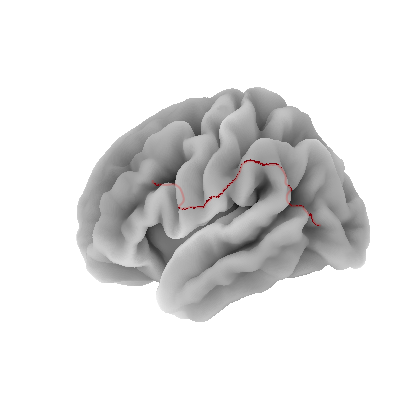

In [101]:
fig = plotting.plot_surf(fsaverage['pial_left'], path_nodes, threshold=1, bg_map=fsaverage['sulc_left'], view='lateral', cmap='Reds')

# plotting.plot_surf_contours(fsaverage[f'pial_left'], labels,
#                                 colors=['k']*201, figure=fig)

# fig.axes[0].plot(x[0], y[0], z[0], marker='.', color='r', markersize=20, alpha=0.3, zorder=4)
# # fig.axes[0].plot(x[-1], y[-1], z[-1], marker='|', color='r', markersize=20, alpha=0.3, zorder=4)
fig.axes[0].plot(x,y,z, color='r', alpha=0.2, zorder=4)


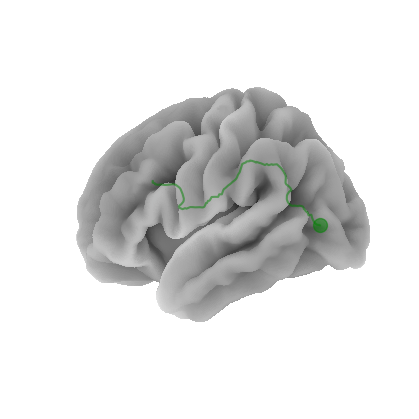

In [103]:
fig = plotting.plot_surf(fsaverage['pial_left'], fsaverage['sulc_left'], view='lateral', cmap='cet_CET_L2_r')

# plotting.plot_surf_contours(fsaverage[f'pial_left'], labels,
#                                 colors=['k']*201, figure=fig)

fig.axes[0].plot(x[0], y[0], z[0], marker='.', color='g', markersize=20, alpha=0.5, zorder=4)
fig.axes[0].plot(x,y,z, color='g', alpha=0.5, zorder=4)


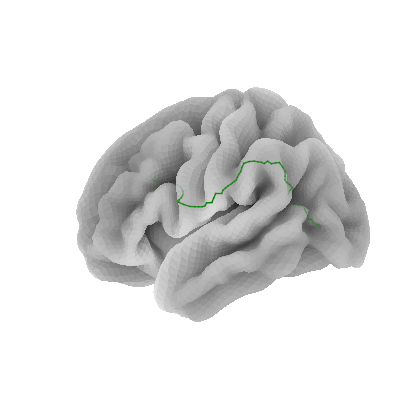

In [71]:
fig = plotting.plot_surf(fsaverage['pial_left'], fsaverage['sulc_left'], view='lateral', cmap='cet_CET_L2_r')

for i in range(len(path) - 1):
    
    p1 = path_coordinates[i, :]
    p2 = path_coordinates[i+1, :]
    shade = path_shading[i]

    if shade < 0:
        linestyle = '-'
    else:
        linestyle = ':'

    fig.axes[0].plot(*zip(p1, p2), alpha=1-shade, color='g', linewidth=1, zorder=4)


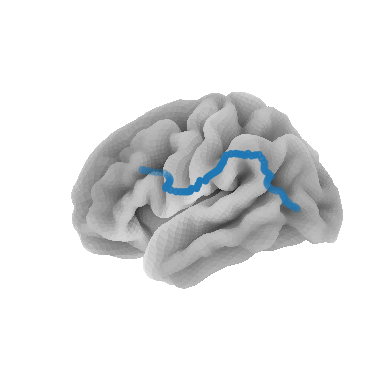

In [88]:
fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'})
ax.computed_zorder = False

display = plotting.plot_surf(fsaverage['pial_left'], fsaverage['sulc_left'], view='lateral', cmap='cet_CET_L2_r', figure=fig, axes=ax)
ax.scatter(x,y,z, zorder=4)
